## Week 5 Exercises

###<font color=green> Replace the name below with **your name**. For full credit, your total needs to add up to **100 points**.

## Kavin Kannan

<font color=purple> *Vera Cooper Rubin, 1928 - 2016, American Astronomer at the Carnegie Institution whose observations of the rotational rates of galaxies uncovered evidence of **dark matter**. She showed that the rotational speeds of tiny portions of distant galaxies did not decrease as expected with distance from the center, but remained higher than expected, leading to the conclusion that there was a far greater mass in the galaxies than was visible. (Her daughter, Judith Young (1952 - 2014), was a Professor of Astronomy at UMass Amherst).*

In [160]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import sin, cos
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import scipy
from scipy.optimize import curve_fit
import pandas as pd

**1. Make a 3D surface plot: atomic orbital.**

a. *(5 points)* Read the 3D Plotting section in the \emph{Getting started with Plotting and Graphics} handout to do this problem.

The ``wave function'' of the electron in a hydrogren atom in the quantum state $n=3$, $\ell=1$, $m=0$ is given by
$$
	\psi(x,y) = x(6-r)e^{-r/3}
$$
where $r=\sqrt{x^2+y^2}$.  Here all distances $x,y,r$ are measured in units of the Bohr radius $a_0 = 5.29\times 10^{-11}$ m.
(The greek letter $\psi$ (psi) is often used for quantum wave functions.)

Define a function to compute $\psi(x,y)$ and make a 3D surface plot of $\psi(x,y)$ over the range ${-20<x<20}$, $-20<y<20$.
If your program is successful, you should see that $\psi(x,y)$ has two large peaks on the $y$ axis (one up  and one down) and two much shallower, wider maxima a bit further out.

Be sure to label your axes and provide a title for your plot.
Set the $z$ label to $\psi(x,y)$ using LaTeX.

*Optional:* If using an IDE such as Spyder,  display your 3D plot in a separate window, and use your mouse to rotate it.
Then, save it to a file and check that you can open up this picture file.

b. *(5 points)*	Use a density plot to show the same $\psi(x,y)$ -- that is, an image that is colored according to the value of $\psi$.  Use `plt.colorbar()` in your plot. Discuss in a markdown cell how the 3D and density plots compare.


Text(0.5, 0.92, 'Surface Plot of $\\psi = x(6-r)e^{\\frac{-r}{3}}$')

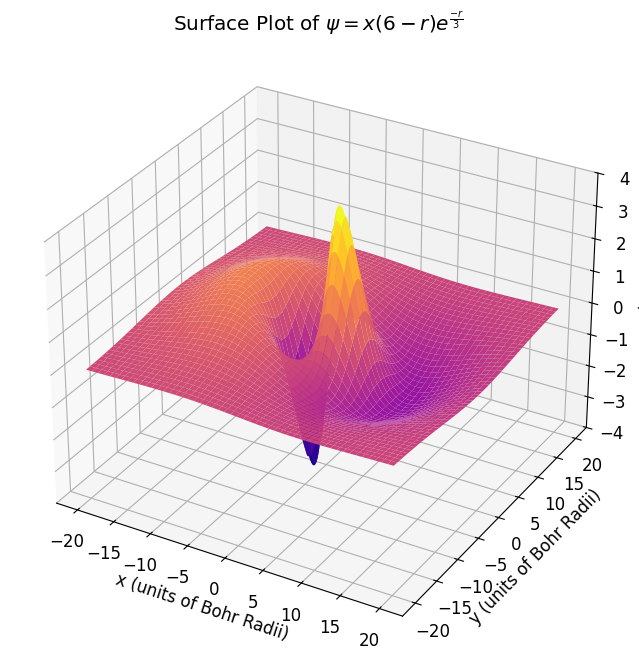

In [84]:
x = np.linspace(-20, 20, 1000)
y = np.linspace(-20, 20, 1000)
psi = []
x, y =np.meshgrid(x, y)
r = np.sqrt(x*x + y*y)
psi = x * (6 - r) * np.exp(-r/3)
psi = np.array(psi)

plt.figure(figsize=(12, 8)) 
plt.rc('font', size=12)        
ax = plt.axes(projection='3d') 
ax.plot_surface(x,y,psi, cmap = 'plasma') 
ax.set_zlim(-4., 4.)
ax.set_xlabel('x (units of Bohr Radii)')
ax.set_ylabel('y (units of Bohr Radii)')
ax.set_zlabel(r'$\psi(x,y)$')
plt.title (r'Surface Plot of $\psi = x(6-r)e^{\frac{-r}{3}}$')

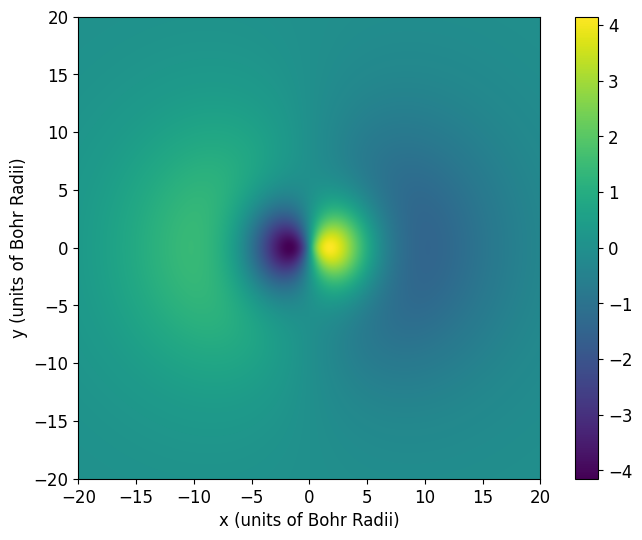

In [85]:
plt.figure(figsize=(9,6)) 
plt.imshow(psi,extent=[-20,20,-20,20])
plt.xlabel('x (units of Bohr Radii)')
plt.ylabel('y (units of Bohr Radii)')
plt.colorbar()

plt.show()

The density plot is simply the 3d plot flattened onto the 2d plane. It is a lot harder to comprehend for us than the 3d plot, but it displays the same information, detailing peaks and divots. We are basically using the colorbar in 2d as the z-axis in 3d.

**2. Make a 3D scatter plot: points on a sphere.** *(10 points)*

The conversion between standard spherical coordinates $r,\theta,\phi$ and cartesian coordinates $x,y,z$ is
\begin{eqnarray*}
x &=& r\sin\theta\cos\phi,\\
y &=& r\sin\theta\sin\phi,\\
z &=& r\cos\theta.
\end{eqnarray*}
Here the radius must obey $r\geq 0$, the polar angle $\theta$ must obey $0 \leq \theta \leq \pi$, and the azimuthal angle $\phi$ must obey $0 \leq \phi \leq 2\pi$.

Make a plot of some points on the surface of a sphere, as follows:
Set $r$ to a fixed value of your choosing.
Start with empty lists for the $x$, $y$ and $z$ coordinates of your points (for example, set `xlist = []`, etc.)
Then use nested `for` statements to vary $\theta$ over $N$ values covering its allowed range, and similarly vary $\phi$ over $N$ points (for example, you can use `for theta in np.linspace(0,pi,nn):`).
For each of these $N^2$ points calculate $x,y,z$ and append to the lists.
Make a 3D scatter plot of the resulting points.  Start with $N=20$ then increase $N$ once your program is working.

Text(0.5, 0.92, 'Scatter Plot of Spherical Coordinates with fixed Radius = 50')

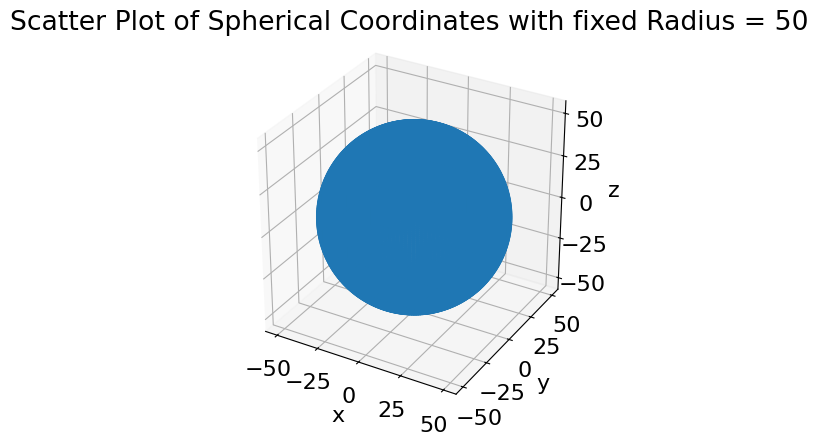

In [294]:
r = 50
N = 150

xlist = []
ylist = []
zlist = []
for theta in np.linspace (0, np.pi, N):
    for phi in np.linspace (0, 2 * np.pi, N):
        xlist.append(r*np.cos(phi)*np.sin(theta))
        ylist.append(r*np.sin(phi)*np.sin(theta))
        zlist.append(r*np.cos(theta))
fig2 = plt.figure()
ax = plt.axes(projection='3d') 
ax.scatter(xlist,ylist,zlist, s = 5) 
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_aspect("equal")
plt.title (f'Scatter Plot of Spherical Coordinates with fixed Radius = {r}')

**3. Radioactive decay: plotting and uncertainty**

Two data files, `decay1.txt` and `decay2.txt`, contain simulated data for measurements of the lifetime of the radioactive isotope $^{116}$In (this experiment is done in Physics 286).
The usual model for such data has the form of an exponential decay:
$$
	N(t) = N_0 e^{-t/\tau} + B
$$
where $N(t)$ represents the number of measured counts per minute at time $t$ after the experiment is started.
$N_0$ is the initial counting rate, $\tau$ is the $^{116}$In lifetime, and $B$ the background counting rate -- or the counting rate observed when the $^{116}$In source is removed.
The objective of the experiment is to measure the lifetime $\tau$ as precisely as possible.

(a) *(10 points)* First read in the two data sets, which are not of the same length, and store them in arrays. Because this counting data is generated randomly, we can estimate the uncertainty (different for every data point $N_j$) as $\sigma_j = \sqrt{N_j}$.
Use this to create an array of $\sigma_j$'s corresponding to each of the two data sets, and plot the data with these $\sigma_j$'s as error bars. Use different symbols for each, and use a legend.

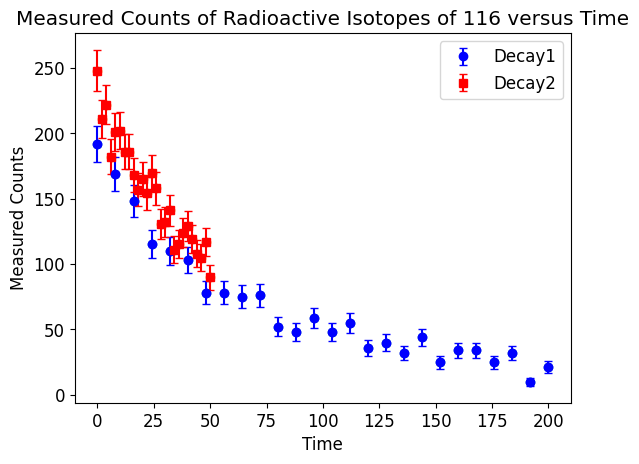

In [ ]:
decay1 = np.loadtxt('decay1.txt', skiprows = 1)
time1 = decay1[:, 0]
n1 = decay1[:, 1]
sigmadecay1 = np.sqrt(n1)
decay2 = np.loadtxt('decay2.txt', skiprows = 1)
time2 = decay2[:, 0]
n2 = decay2[:, 1]
sigmadecay2 = np.sqrt(n2)

plt.scatter(time1, n1)
plt.errorbar(time1, n1, sigmadecay1, fmt = 'bo', capsize = 3, label='Decay1')
plt.scatter(time2, n2)
plt.errorbar(time2, n2, sigmadecay2, fmt = 'rs', capsize = 3,  label='Decay2')
plt.xlabel('Time (s)')
plt.ylabel('Measured Counts')
plt.title('Measured Counts of Radioactive Isotopes of 116 versus Time')
plt.legend()
plt.show()

(b) *(5 points)* The error bars should be bigger near the start of each plot. Why is this? Now, make the $N$ axis (i.e., the y-axis) of your $N(t)$ plots logarithmic.  Both plots should look like straight lines, and the error bars should be bigger near the ends of the plots. Why is this? Explain these observations in a docstring/markdown cell.

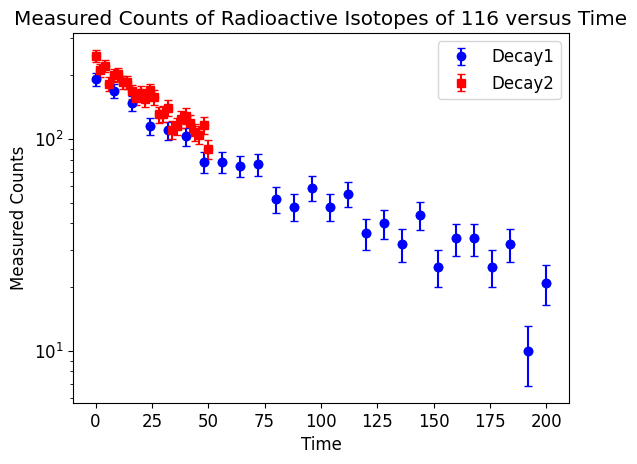

In [ ]:
plt.scatter(time1, n1)
plt.errorbar(time1, n1, sigmadecay1, fmt = 'bo', capsize = 3, label='Decay1')
plt.scatter(time2, n2)
plt.errorbar(time2, n2, sigmadecay2, fmt = 'rs', capsize = 3,  label='Decay2')
plt.yscale('log') 
plt.xlabel('Time (s)')
plt.ylabel('Measured Counts')
plt.title('Measured Counts of Radioactive Isotopes of 116 versus Time')
plt.legend()
plt.show()

The error bars in the first part are wider when time is closer to 0, as measured counts during that period is way higher than other points, thus making sigma a lot greater as well. However, when switching over to the log scale, sigma becomes greater near the later times as the scale of the Measured Counts is much greater towards the top, thus, the error bars will be smaller as the y scaling is greater there. 

**4. Radioactive decay - fitting the data**

Fit the model defined in Problem 3 to each of the two data sets, in two different ways:

(a) *(5 points)* Do a **three-parameter** fit, with $N_0$, $\tau$, and $B$ all determined by the fit. For both sets of data, show the data set as a set of symbols with error bars, and show the fits as lines that have the same color as the data points.

12.15875275777489 +/- 5.160037258101487
35.588112119379176 +/- 46.103446521967236


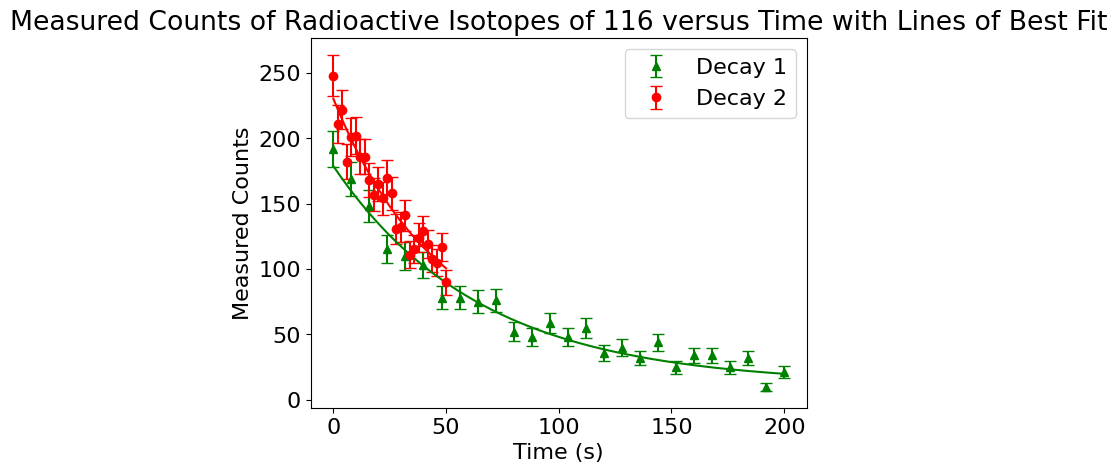

In [299]:
def MeasuredCounts(t, N0, tao, B):
    return N0 * np.exp(-t/tao) + B

pp = 3   # number of fitting parameters

guesses1 = (250, 25, 100)

sigmadecay1 = np.array(sigmadecay1)
(N01, tao1, B1), cc = curve_fit(MeasuredCounts, time1, n1, p0 = guesses1, sigma = sigmadecay1)
(up01, up11, up21) = np.sqrt(np.diag(cc))

timem1 = np.linspace(time1[0], time1[-1], 200)
nm1 = MeasuredCounts(timem1, N01, tao1, B1)
print(f"{B1} +/- {up21}")

guesses2 = (195, 100, 10)

sigmadecay2 = np.array(sigmadecay2)
(N02, tao2, B2), cc = curve_fit(MeasuredCounts, time2, n2, p0 = guesses2, sigma = sigmadecay2)
(up02, up12, up22) = np.sqrt(np.diag(cc))

timem2 = np.linspace(time2[0], time2[-1], 200)
nm2 = MeasuredCounts(timem2, N02, tao2, B2)
print(f"{B2} +/- {up22}")

plt.errorbar(time1,n1,sigmadecay1, fmt = 'g^', capsize = 4, label='Decay 1')
plt.errorbar(time2,n2,sigmadecay2, fmt = 'ro', capsize = 4, label='Decay 2')
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Measured Counts')
plt.title('Measured Counts of Radioactive Isotopes of 116 versus Time with Lines of Best Fit')
plt.plot(timem1, nm1, 'g')
plt.plot(timem2, nm2, 'r')
plt.show()

(b) *(5 points)* Assume a separate experiment has been done without the $^{116}$In source present to measure $B =$ 25 cts/min.
Fix $B$ at this value, and do a **two-parameter** fit with $N_0$ and $\tau$ as the fitting parameters. Once again, for both data sets, show the data as symbols with error bars, and show the fits as lines that have the same color as the corresponding data points.  

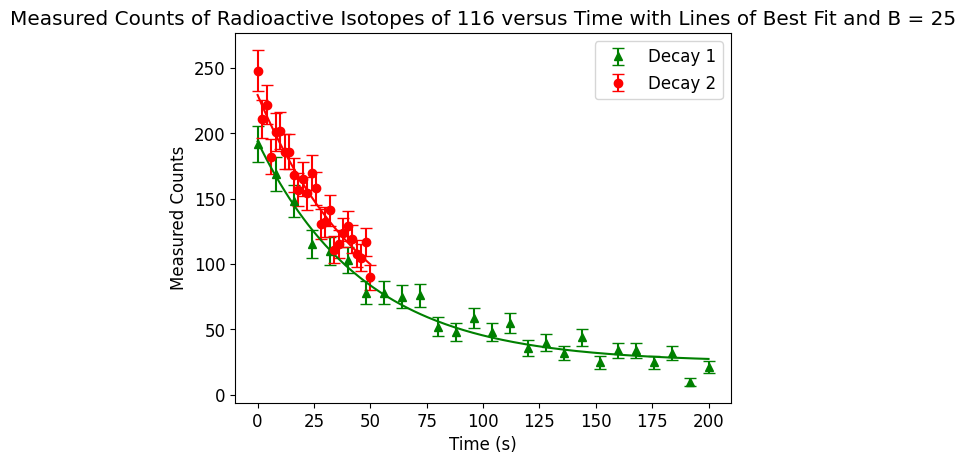

In [116]:
def MeasuredCountsBfixed(t, N0, tao):
    return N0 * np.exp(-t/tao) + 25

pp = 2   # number of fitting parameters

guesses1B = (250, 25)

sigmadecay1B = np.array(sigmadecay1)
(N01B, tao1B), cc = curve_fit(MeasuredCountsBfixed, time1, n1, p0 = guesses1B, sigma = sigmadecay1B)
(up01B, up11B) = np.sqrt(np.diag(cc))

timem1B = np.linspace(time1[0], time1[-1], 200)
nm1B = MeasuredCountsBfixed(timem1B, N01B, tao1B)

guesses2B = (195, 100)

sigmadecay2B = np.array(sigmadecay2)
(N02B, tao2B), cc = curve_fit(MeasuredCountsBfixed, time2, n2, p0 = guesses2B, sigma = sigmadecay2B)
(up02B, up12B) = np.sqrt(np.diag(cc))

timem2B = np.linspace(time2[0], time2[-1], 200)
nm2B = MeasuredCountsBfixed(timem2B, N02B, tao2B)

plt.errorbar(time1,n1,sigmadecay1, fmt = 'g^', capsize = 4, label='Decay 1')
plt.errorbar(time2,n2,sigmadecay2, fmt = 'ro', capsize = 4, label='Decay 2')
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Measured Counts')
plt.title('Measured Counts of Radioactive Isotopes of 116 versus Time with Lines of Best Fit and B = 25')
plt.plot(timem1B, nm1B, 'g')
plt.plot(timem2B, nm2B, 'r')
plt.show()

(c) *(5 points)* **For each of these four fits** (two data sets, two ways), output the result for $\tau$ and its uncertainty, and compare with the accepted value $\tau = 54.3$ min. Also compute and compare the $\chi_r^2$ for the two fits. Which fit works best for the first data set? Which for the second? Respond in a markdown cell.

You should find that the data set covering a longer time works well whether or not $B$ is determined separately, but the shorter time data set works much better with a separately-determined $B$. Why is this?

In [ ]:
print("Tau for Decay 1:", tao1, "±", up11)
dof1 = len(time1) - (1 + 1 + 1)
residuals1 = (n1 - MeasuredCountsBfixed(time1, N01, tao1)) / sigmadecay1
chi1 = np.sum(residuals1 ** 2)
redchi1 = chi1 / dof1
print("Reduced Chi Squared for Decay 1:", redchi1)

print("Tau for Decay 2:", tao2, "±", up12)
dof2 = len(time2) - (1 + 1 + 1)
residuals2 = (n2 - MeasuredCountsBfixed(time2, N02, tao2)) / sigmadecay2
chi2 = np.sum(residuals2 ** 2)
redchi2 = chi2 / dof2
print("Reduced Chi Squared for Decay 2:", redchi2)

print("Tao for Decay 1 (with B fixed):", tao1B, "±", up11B)
dof1B = len(time1) - (1 + 1)
residuals1B = (n1 - MeasuredCountsBfixed(time1, N01B, tao1B)) / sigmadecay1B
chi1B = np.sum(residuals1B ** 2)
redchi1B = chi1B / dof1B
print("Reduced Chi Squared for Decay 1 with fixed B:", redchi1B)

print("Tau for Decay 2 (with B fixed):", tao2B, "±", up12B)
dof2B = len(time2) - (1 + 1)
residuals2B = (n2 - MeasuredCountsBfixed(time2, N02B, tao2B)) / sigmadecay2B
chi2B = np.sum(residuals2B ** 2)
redchi2B = chi2B / dof2B
print("Reduced Chi Squared for Decay 2 with fixed B:", redchi2B)



Tau for Decay 1: 65.20572800118237 ± 8.646741575441256
Reduced Chi Squared for Decay 1: 6.110661456041426
Tau for Decay 2: 45.573642479580805 ± 18.48268972550598
Reduced Chi Squared for Decay 2: 1.7174706230713301
Tao for Decay 1 (with B fixed): 47.3650560768315 ± 3.864734090120285
Reduced Chi Squared for Decay 1 with fixed B: 2.242054666289028
Tau for Decay 2 (with B fixed): 49.78213752956595 ± 2.9139101120536144
Reduced Chi Squared for Decay 2 with fixed B: 0.8103327099465648


The time being shorter means the exponential decay hasn't taken full effect yet and stablized around 0. Thus, the y-intercept (or B in our case) has more of a role in the shorter time dataset. Thus, predetermining it will have a way bigger effect as the fit can't determine it to be around 0.

**5. Parameter guesses in nonlinear fits.**
Try the 5-parameter (Gaussian + linear background) fit to the data in file `peak4.txt` used in the **Fitting models to data** handout by doing the following:

(a) *(5 points)* Start with initial parameter guesses that are all equal to 1, and see what happens. Starting with parameter values equal to 1 worked fine for a linear model like the polynomial (which has only one minimum in $\chi_r^2$) but you should find that it doesn't work here.

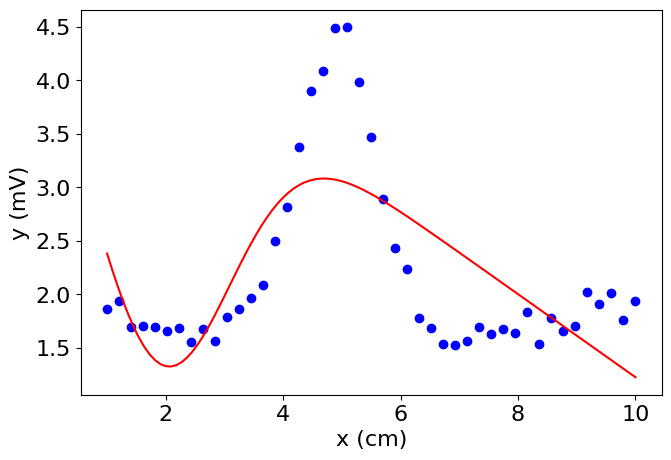

reduced chi-squared = 0.39197925358408703
parameters and 2-sigma parameter uncertainties:
A = -3.019737 +/- 1.084504
x0 = 1.869350 +/- 0.410304
w = -1.214992 +/- 0.554832
B0 = 5.107198 +/- 1.386184
B1 = -0.388178 +/- 0.178823


In [231]:
# read the data from file
data = np.loadtxt('peak4.txt', float,skiprows=1) # read into 2D array
x = data[:,0]
y = data[:,1]
nn = len(x)        # number of data points

# model function
def f(x,aa,x0,w,bb0,bb1):
    """Model function: Gaussian centered at x0 plus linear background"""
    return aa*np.exp(-(x-x0)**2/(2*w**2)) + bb0 + bb1*x
pp = 5              # number of parameters: aa, x0, w, bb0, bb1 (3 for Gaussian, 2 for linear function)

guesses = [1,1,1,1,1]   # parameter guesses
(aa,x0,w,bb0,bb1),cc = curve_fit(f,x,y,p0=guesses) # do the fit
(uaa,ux0,uw,ubb0,ubb1) = 2*np.sqrt(np.diag(cc)) # 2-sigma uncertainties of parameters

yfit = f(x,aa,x0,w,bb0,bb1)
yys = (yfit-y)**2
chisqr = sum(yys)/(nn-pp)                # compute reduced chi-squared

# plot data and model together
xmod = np.linspace(x[0],x[-1],100)       # assumes x's are in order
ymod = f(xmod,aa,x0,w,bb0,bb1)
plt.figure(figsize=(7.5,5))
plt.rc('font', size=16)
plt.plot(x,y,'bo') # plot the data
plt.plot(xmod,ymod,'r')                  # plot the model
plt.xlabel('x (cm)')
plt.ylabel('y (mV)')
plt.show()

# report results
print('reduced chi-squared =',chisqr)
print('parameters and 2-sigma parameter uncertainties:')
print('A = %f +/- %f'%(aa,uaa))
print('x0 = %f +/- %f'%(x0,ux0))
print('w = %f +/- %f'%(w,uw))
print('B0 = %f +/- %f'%(bb0,ubb0))
print('B1 = %f +/- %f'%(bb1,ubb1))

(b) *(5 points)* Which of the five initial parameter values is the non-linear least squares fitting most sensitive to? Change each initial parameter guess in turn to address this question.  What range of values of each allows you to successfully find the global minimum in $\chi_r^2$? Report your answer in a markdown cell. This points to the importance of having a good guess for a fitting model function.

The second term (x0) is the parameter which the non-linear least squares fitting is most sensitive to. This is because it marks the center of the Gaussian, so if it is off by a lot, the whole Gaussian can't really adjust around it. 
x0 should be around 5, A should be near 2.7, w should be near -0.6, B0 should be near 1.7, and B1 should be almost 0.


(c) *(5 points)* Fit the data in `peak4.txt` using one less parameter, so the model is a Gaussian plus a constant background. How does this fit perform in comparison to the linear background term used in the previous part? In each case, compare $\chi_r^2$.

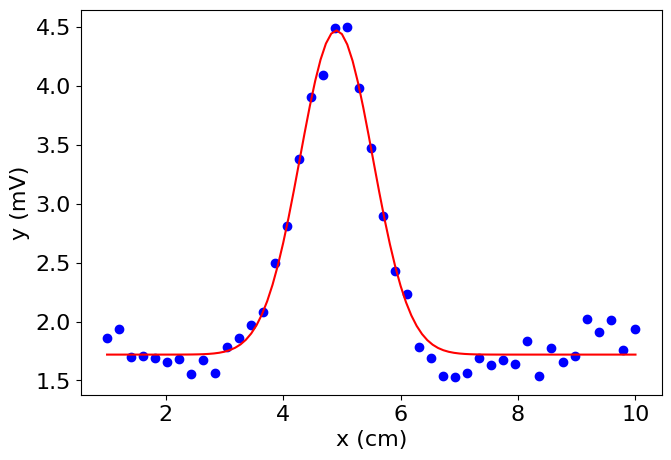

reduced chi-squared = 0.017468866133840112
parameters and 2-sigma parameter uncertainties:
A = 2.749958 +/- 0.143860
x0 = 4.906026 +/- 0.036385
w = -0.620760 +/- 0.039630
B0 = 1.719683 +/- 0.049203


In [140]:
# read the data from file
data = np.loadtxt('peak4.txt', float,skiprows=1) # read into 2D array
x = data[:,0]
y = data[:,1]
nn = len(x)        # number of data points

# model function
def fnew(x,aa,x0,w,bb0):
    """Model function: Gaussian centered at x0 with no linear background"""
    return aa*np.exp(-(x-x0)**2/(2*w**2)) + bb0 
pp = 4              # number of parameters: aa, x0, w, bb0, bb1 (3 for Gaussian, 2 for linear function)

guesses = [2.7,5,-0.6,1.7]   # parameter guesses
(aa,x0,w,bb0),cc = curve_fit(fnew,x,y,p0=guesses) # do the fit
(uaa,ux0,uw,ubb0) = 2*np.sqrt(np.diag(cc)) # 2-sigma uncertainties of parameters

yfit = fnew(x,aa,x0,w,bb0)
yys = (yfit-y)**2
chisqr = sum(yys)/(nn-pp)                # compute reduced chi-squared

# plot data and model together
xmod = np.linspace(x[0],x[-1],100)       # assumes x's are in order
ymod = fnew(xmod,aa,x0,w,bb0)
plt.figure(figsize=(7.5,5))
plt.rc('font', size=16)
plt.plot(x,y,'bo') # plot the data
plt.plot(xmod,ymod,'r')                  # plot the model
plt.xlabel('x (cm)')
plt.ylabel('y (mV)')
plt.show()

# report results
print('reduced chi-squared =',chisqr)
print('parameters and 2-sigma parameter uncertainties:')
print('A = %f +/- %f'%(aa,uaa))
print('x0 = %f +/- %f'%(x0,ux0))
print('w = %f +/- %f'%(w,uw))
print('B0 = %f +/- %f'%(bb0,ubb0))

Chi Squared is almost the same without the B1 term seeing as it was so close to 0 anyways. 

**6. Gaussian vs Lorentzian fits**

The following two functions both describe peaks of height A and width w centered at $x_0$, with constant additive background B:

$$
f_\text{gauss}(x) =  A \exp(-[x-x_0]^2/2w^2) + B \\
f_\text {lorentz}(x) = \frac{A}{1 + [(x-x_0)/w]^2} + B.
$$

The first function $f_\text{gauss}(x)$ is the by-now familiar Gaussian peak.
The second function $f_\text {lorentz}(x)$ is called a Lorentzian - it occurs naturally in resonant phenomena such as optical transitions of atoms or damped driven harmonic oscillators.

(a) *(5 points)* Create two user-defined functions for the Gaussian and Lorentzian forms described above. The function definitions should include all four required parameters for each type of fit.

In [147]:
def fgauss(x, A, x0, w, B):
    return A * np.exp(-((x-x0)**2) / (2 * w**2)) + B

def florentz(x, A, x0, w, B):
    return (A / (1+((x-x0)/(w))**2)) + B

(b) *(5 points)* Read in the data files `gl1.txt` and `gl2.txt` and fit to both Gaussian and Lorentzian functions using `curve_fit()`.  Print out the fit parameters and their uncertainties, and the corresponding $\chi^2_r$ values for each fit.

Comment in a docstring or markdown cell which type of function best describes each data set. You should base this analysis on what you printed out in the previous step.

*Note: Since these data sets do not have specified uncertainties, you should not expect to find the reported $\chi^2_r = 1$.
Nevertheless, it still makes sense to compare $\chi^2_r$ between the two types of fit to help determine which function fits the data set better.*

GAUSS DATASET 1 reduced chi-squared = 0.005301599295895532
parameters and 2-sigma parameter uncertainties:
A = 1.302816 +/- 0.079755
x0 = -0.729480 +/- 0.122986
w = 1.823871 +/- 0.140056
B0 = -0.189197 +/- 0.033845


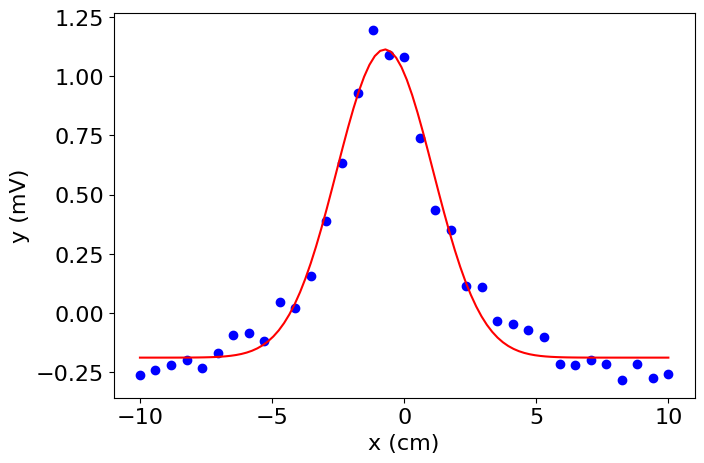

LORENTZ DATA SET 1 reduced chi-squared = 0.002039931679320031
parameters and 2-sigma parameter uncertainties:
A = 1.513726 +/- 0.056488
x0 = -0.742944 +/- 0.073893
w = 2.045883 +/- 0.150199
B0 = -0.313164 +/- 0.029993
GAUSS DATA SET 2 reduced chi-squared = 0.00212294146664352
parameters and 2-sigma parameter uncertainties:
A = 1.534222 +/- 0.048212
x0 = 0.677277 +/- 0.069976
w = 2.044882 +/- 0.081995
B0 = -0.316997 +/- 0.022675
LORENTZ DATA SET 2 reduced chi-squared = 0.0046058894310380795
parameters and 2-sigma parameter uncertainties:
A = 1.776797 +/- 0.080683
x0 = 0.678482 +/- 0.102215
w = 2.387223 +/- 0.222754
B0 = -0.488019 +/- 0.050751


In [300]:
gl1 = np.loadtxt("gl1.txt", skiprows=1)
x1 = gl1[:, 0]
y1 = gl1[:, 1]
nn = len(x1)
pp = 4

guesses = [1.2,0,2,0]   # parameter guesses
(A, x0, w, B),cc = curve_fit(fgauss,x1,y1,p0=guesses) # do the fit
(uA,ux0,uw,uB) = 2*np.sqrt(np.diag(cc)) # 2-sigma uncertainties of parameters

yfit = fgauss(x1,A,x0,w,B)
yys = (yfit-y1)**2
chisqr = sum(yys)/(nn-pp)                # compute reduced chi-squared
print('GAUSS DATASET 1 reduced chi-squared =', chisqr)
print('parameters and 2-sigma parameter uncertainties:')
print('A = %f +/- %f'%(A,uA))
print('x0 = %f +/- %f'%(x0,ux0))
print('w = %f +/- %f'%(w,uw))
print('B0 = %f +/- %f'%(B,uB))

# plot data and model together
xmod = np.linspace(x1[0],x1[-1],100)       # assumes x's are in order
ymod = fnew(xmod,A,x0,w,B)
plt.figure(figsize=(7.5,5))
plt.rc('font', size=16)
plt.plot(x1,y1,'bo') # plot the data
plt.plot(xmod,ymod,'r')                  # plot the model
plt.xlabel('x (cm)')
plt.ylabel('y (mV)')
plt.show()



##########################################################################################################

guesses = [1.2,0,2,0]   # parameter guesses
(A, x0, w, B),cc = curve_fit(florentz,x1,y1,p0=guesses) # do the fit
(uA,ux0,uw,uB) = 2*np.sqrt(np.diag(cc)) # 2-sigma uncertainties of parameters

yfit = florentz(x1,A,x0,w,B)
yys = (yfit-y1)**2
chisqr = sum(yys)/(nn-pp)                # compute reduced chi-squared
print('LORENTZ DATA SET 1 reduced chi-squared =', chisqr)
print('parameters and 2-sigma parameter uncertainties:')
print('A = %f +/- %f'%(A,uA))
print('x0 = %f +/- %f'%(x0,ux0))
print('w = %f +/- %f'%(w,uw))
print('B0 = %f +/- %f'%(B,uB))

##########################################################################################################

gl2 = np.loadtxt("gl2.txt", skiprows=1)
x2 = gl2[:, 0]
y2 = gl2[:, 1]
nn=len(x2)
pp = 4

guesses = [1,1,1,1]   # parameter guesses
(A, x0, w, B),cc = curve_fit(fgauss,x2,y2,p0=guesses) # do the fit
(uA,ux0,uw,uB) = 2*np.sqrt(np.diag(cc)) # 2-sigma uncertainties of parameters

yfit = fgauss(x2,A,x0,w,B)
yys = (yfit-y2)**2
chisqr = sum(yys)/(nn-pp)                # compute reduced chi-squared
print('GAUSS DATA SET 2 reduced chi-squared =', chisqr)
print('parameters and 2-sigma parameter uncertainties:')
print('A = %f +/- %f'%(A,uA))
print('x0 = %f +/- %f'%(x0,ux0))
print('w = %f +/- %f'%(w,uw))
print('B0 = %f +/- %f'%(B,uB))

##########################################################################################################

guesses = [1,1,1,1]   # parameter guesses
(A, x0, w, B),cc = curve_fit(florentz,x2,y2,p0=guesses) # do the fit
(uA,ux0,uw,uB) = 2*np.sqrt(np.diag(cc)) # 2-sigma uncertainties of parameters

yfit = florentz(x2,A,x0,w,B)
yys = (yfit-y2)**2
chisqr = sum(yys)/(nn-pp) # compute reduced chi-squared
print('LORENTZ DATA SET 2 reduced chi-squared =', chisqr)
print('parameters and 2-sigma parameter uncertainties:')
print('A = %f +/- %f'%(A,uA))
print('x0 = %f +/- %f'%(x0,ux0))
print('w = %f +/- %f'%(w,uw))
print('B0 = %f +/- %f'%(B,uB))


The best fits for the datasets are Lorentz for Set 1, and Gauss for set 2. 

**7. Resonance in a LRC Circuit**

(a) *(5 points)* Read in two data files named `P182_LRC_resonance1.csv` and `P182_LRC_resonance2.csv`, and store them as two separate data arrays.  Slice these arrays into separate x and y values, and plot them on the same plot. Using the Lorentzian fit function you defined in Exercise 6, separately create model fits to both.  Print out the fit parameters and their uncertainties, and the corresponding $\chi^2_r$ values for each fit.

Lorentz Data Set 1 reduced chi-squared = 0.001963677055236043
parameters and 2-sigma parameter uncertainties:
A = 0.715426 +/- 0.048598
x0 = 1409.653493 +/- 15.508625
w = 238.237430 +/- 35.808172
B = 0.095594 +/- 0.042853


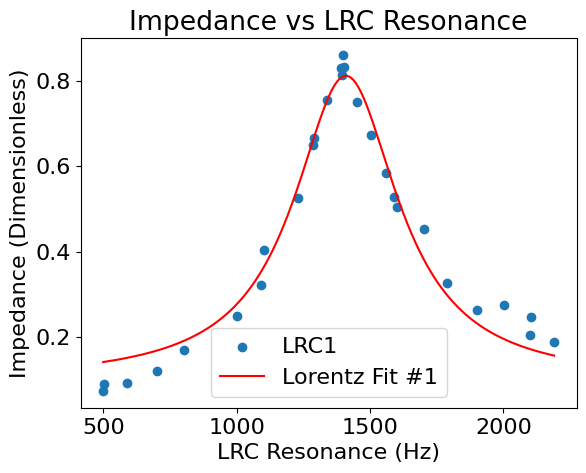

Lorentz Data Set 1 reduced chi-squared = 0.0009044875978164534
parameters and 2-sigma parameter uncertainties:
A = 0.468833 +/- 0.025304
x0 = 1397.368418 +/- 7.982871
w = 101.173282 +/- 11.538501
B = 0.036331 +/- 0.013800


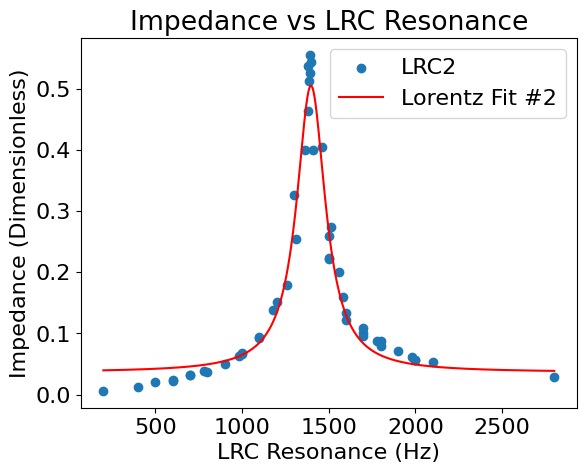

In [263]:
LRC1 = np.array(pd.read_csv('P182_LRC_resonance1.csv', skiprows = 1))
LRC2 = np.array(pd.read_csv('P182_LRC_resonance2.csv', skiprows = 1))

x1 = LRC1[:, 0]
y1 = LRC1[:, 1]
x2 = LRC2[:, 0]
y2 = LRC2[:, 1]

nn=len(x1)
pp = 4

guesses = [1,np.mean(x1),1,np.min(y1)]   # parameter guesses
(A, x0, w, B),cc = curve_fit(florentz,x1,y1,p0=guesses) # do the fit
(uA,ux0,uw,uB) = 2*np.sqrt(np.diag(cc)) # 2-sigma uncertainties of parameters
yfit = florentz(x1,A,x0,w,B)

rcsq = sum((y1 - yfit)**2)/(nn-pp) # compute reduced chi-squared

print('Lorentz Data Set 1 reduced chi-squared =', rcsq)
print('parameters and 2-sigma parameter uncertainties:')
print('A = %f +/- %f'%(A,uA))
print('x0 = %f +/- %f'%(x0,ux0))
print('w = %f +/- %f'%(w,uw))
print('B = %f +/- %f'%(B,uB))

x1_sorted = np.sort(x1)
xmod = np.linspace(x1_sorted[0],x1_sorted[-1],1000)       # assumes x's are in order
ymod = florentz(xmod,A,x0,w,B)

plt.scatter(x1,y1, label = "LRC1")
plt.title("Impedance vs LRC Resonance")
plt.ylabel("Impedance (Dimensionless)")
plt.xlabel("LRC Resonance (Hz)")
plt.plot(xmod,ymod,'r', label="Lorentz Fit #1")    
plt.legend()              # plot the model
plt.show()

##########################################################################################################

nn=len(x2)
pp = 4

guesses = [1,np.mean(x2),1,np.min(y2)]   # parameter guesses
(A, x0, w, B),cc = curve_fit(florentz,x2,y2,p0=guesses) # do the fit
(uA,ux0,uw,uB) = 2*np.sqrt(np.diag(cc)) # 2-sigma uncertainties of parameters
yfit = florentz(x2,A,x0,w,B)

rcsq = sum((y2 - yfit)**2)/(nn-pp) # compute reduced chi-squared

print('Lorentz Data Set 1 reduced chi-squared =', rcsq)
print('parameters and 2-sigma parameter uncertainties:')
print('A = %f +/- %f'%(A,uA))
print('x0 = %f +/- %f'%(x0,ux0))
print('w = %f +/- %f'%(w,uw))
print('B = %f +/- %f'%(B,uB))

x2_sorted = np.sort(x2)
xmod = np.linspace(x2_sorted[0],x2_sorted[-1],1000)       # assumes x's are in order
ymod = florentz(xmod,A,x0,w,B)

plt.scatter(x2,y2, label = "LRC2")
plt.title("Impedance vs LRC Resonance")
plt.ylabel("Impedance (Dimensionless)")
plt.xlabel("LRC Resonance (Hz)")
plt.plot(xmod,ymod,'r', label="Lorentz Fit #2")  
plt.legend()
plt.show()


(c) *(5 points)* These data represent two sets of experimental measurements, carried out by students in Physics 182, of the resonance response in an inductor-resistor-capacitor, or LRC circuit, with one of the physical elements (L, R, C) changing. Looking at the parameter values generated, which parameter changes the most from one fit to the next? What does this imply in terms of the physical values of R, L and C? Explain in a markdown cell.

The parameter that changes most between the 2 measurements is w. This suggests that R likely was very different between the 2 trials. 

**8. Use complex numbers to analyze an AC circuit.** *(10 points)*

An AC (alternating-current) circuit is an electronic circuit in which the voltages and currents are oscillating functions of time, for example:
\begin{align*}
i(t) &= I_0\cos(\omega t + \phi_I) &\mbox{current through a resistor,}\\
v(t) &= V_0\cos(\omega t + \phi_V) &\mbox{voltage across the resistor.}
\end{align*}

The angular frequency $\omega = 2\pi f$ is the same for all parts of the circuit.

A standard way to deal with the algebra is to represent the time-dependent oscillating currents and voltages by \textbf{complex numbers $I,V$ that don't depend on time}.~\footnote{
The amplitude and phase of the complex number $I$ are used to represent the amplitude $I_0$ and phase $\phi_I$ of $i(t)$.
The formula to get $i(t)$ back from the time-independent $I$ is $i(t) = \mbox{Re}[I \exp(i\omega t)]$, but this is not needed for this problem.}

Using $I,V$ in place of the usual (real) currents and voltages $i(t),v(t)$, we analyze an AC circuit as if it were a DC (time-independent) circuit.  

We use Ohm's law $I = V/R$ and Kirchhoff's rules.  that the sum of all the currents into a junction must be zero.
The only difference is that in place of the resistance $R$, for capacitors and inductors we use the ``impedance'' $Z$ which is a complex number given by:
\begin{align*}
Z_L &= i\omega L &\mbox{for an inductor with inductance $L$,}\\
Z_C &= \frac{1}{i\omega C} &\mbox{for a capacitor with capacitance $C$.}
\end{align*}
The current is given by Ohm's law with the resistance replaced by the total impedance: $I=V/Z_t$, where the effective impedance $Z_t$ depends on the circuit.  Given $V$, you compute $Z_t$ as a complex, frequency-dependent quantity, then plot $I=V/Z_t$ as a function of frequency $f=\omega/2\pi$.  

The circuit you will analyze is a series RLC circuit. Since resistor $R$, inductor $L$, and capacitor $C$ are in \textbf{series}, the total impedance of the circuit is the sum of the three individual impedances, $Z_t = R + Z_L + Z_C$.

Generate an array of frequencies over the range $f = 10$ - 250~kHz,  calculate the total impedance $Z_t$ and the current $I = V/Z_t$ over this range and then plot, on the same graph, the real and imaginary parts of $I = V/Z$ as a function of frequency $f $.  The plot should appear as shown below. Be sure to include axes labels, a title, and legends using \verb7plt.legend()7.

Notice that the resonance peak in Re[$I$] is at the special frequency $f_0 = 1/(2\pi\sqrt{LC}) = 119$~kHz, which is the natural frequency of a  pure LC circuit (which is analogous to a simple harmonic oscillator).

**9. Simulating Radioactive Decay**  *(15 points)*
In Exercises 3 and 4, you looked at data from a radioactive decay experiment. Here, you will do a simple Monte Carlo simulation of the decay of a population of atoms.

Consider $N$ atoms of a radioactive element of decay lifetime $\tau$. The probability that a given nucleus will decay in time $\Delta t$ is $p = \Delta t/\tau$. Track the population of undecayed nuclei as a function of time using the following procedure.:

- Divide the total time over which you wish to compute the decay into `nsteps` equal intervals of size $\Delta t$.
- Store the number of undecayed atoms in an integer array of size  `nsteps`
- At each time step, use the following Monte Carlo procedure to decide if a given nucleus should decay. Pick a random number $r$ using `rng.random()`, and if the probability $p >r$, the nucleus should decay (i.e. the number of undecayed nuclei drops by 1).  Loop over all undecayed nuclei at each time step.
- Run this entire simulation a few times, say for 10 trials, i.e. starting from the same starting number of nuclei. This should be equivalent to having 10 different experiments.
- Once complete, plot the number of undecayed nuclei as a function of time for each of your trials using points. What shape does this have? Does it resemble your radioactive decay plots from earlier?


Start with $N_0 = 1000$ $^{14}C$ nuclei which have lifetime of 8267 years.  Track the decay over a period of 20,000 years in `nsteps = 200` timesteps.

*(5 points)* **Bonus:** average over trials and fit the data to an exponential decay and extract the half life of $^{14}C$. The half life is defined as the time taken for the number of radioactive nuclei to drop by 50 \%.

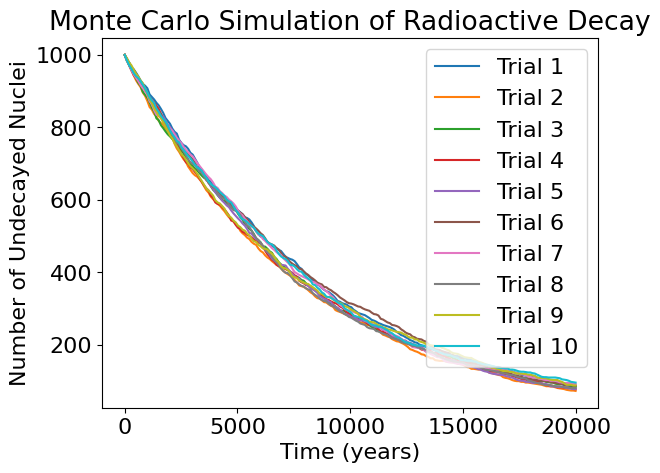

In [306]:
rng = np.random.default_rng()

def carlos(n0, tau, Nsteps, time, Ntrials):
    storage = np.zeros((Ntrials, Nsteps))
    step_size = time / Nsteps
    p = step_size / tau
    for trial in range(Ntrials):
        n = n0 
        N_undecayed = np.zeros(Nsteps)
        for i in range(Nsteps):
            N_undecayed[i] = n  # indexing
            r = rng.random(n)  # n random numbers
            decayed = np.sum(r < p)  # Count decayed nuclei
            n -= decayed  # Update remaining nuclei
        storage[trial, :] = N_undecayed
    for trial in range(Ntrials):
        plt.plot(np.linspace(0, time, Nsteps), storage[trial], label=f'Trial {trial+1}')
        plt.xlabel("Time (years)")
        plt.ylabel("Number of Undecayed Nuclei")
        plt.title("Monte Carlo Simulation of Radioactive Decay")
        plt.legend()
    plt.show()

carlos(1000, 8267, 200, 20000, 10)